# Load Libraries

In [27]:
from project_config import load_user_paths
USER_PATHS = load_user_paths()

%load_ext autoreload
%autoreload 1
%aimport interactive_figures




# Basic libraries
import pandas as pd
import numpy as np
import sys



# Scipy
import scipy
from scipy import signal
from scipy.linalg import solve
from scipy import constants
from scipy.interpolate import interp1d
from scipy.fft import fft, fftfreq

# Locate files
import os
from pathlib import Path
from glob import glob

# Plots
from matplotlib import pyplot as plt

#Important!! Make sure your current directory is the MHDTurbPy folder!
os.chdir(USER_PATHS['repo_root'])


# Make sure to use the local spedas
sys.path.insert(0, os.path.join(os.getcwd(), 'pyspedas'))
import pyspedas
from pyspedas.utilities import time_string
from pytplot import get_data
from joblib import Parallel, delayed

""" Import manual functions """

sys.path.insert(1, os.path.join(os.getcwd(), 'functions'))
import calc_diagnostics as calc
import TurbPy as turb
import general_functions as func
import Figures as figs
import interactive_figs

from   SEA import SEA
import three_D_funcs as threeD
import download_data as download

sys.path.insert(1, os.path.join(os.getcwd(), 'functions/3d_anis_analysis_toolboox'))
import collect_wave_coeffs 
import data_analysis 



os.environ["CDF_LIB"] = "/Applications/cdf/cdf/lib"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
MISSION = {"sc": "ACE", "in_rtn": False}

vars_2_downnload = {
    "mag": None,
    "par": None,   # or "swe": None
}


In [25]:
from project_config import load_user_paths
USER_PATHS = load_user_paths()


from __future__ import annotations

import os
from pathlib import Path
from joblib import Parallel, delayed

import download_data as download


# ============================================================
# 0) Environment / paths
# ============================================================

# Point this to your local CDF library (needed for some CDAS / CDF readers)
cdf_lib_path = USER_PATHS['cdf_lib_path']

# Credentials are optional (public products will still work when available).
# For private FIELDS/SWEAP products, fill these in.
credentials             =      { 'psp':{
                                           'fields': {'username': 'mvelli', 'password': 'flds@psp'},
                                           'sweap' : {'username': 'mvelli', 'password': '2019swe@pd@ta'}}}

# If you truly want no credentials:
# credentials = None


# ============================================================
# 1) Settings (tightly organized by topic)
# ============================================================

# ---- Paths / IO
PATHS = {
                "Data_path"          : USER_PATHS["Data_path"],                           # IMPORTANT: keep repo root for local imports
                "save_destination"   : USER_PATHS["save_destination"],       # where interval folders are created
}

IO = {
                "overwrite_files"               : 1,        # 1 -> overwrite folders if final.pkl exists
                "save_all"                      : True,     # True -> save final.pkl + general.pkl (+ extras)
                "addit_time_around"             : 1,        # hours padded around each interval for loading
                "gap_time_threshold"            : 5,        # legacy (used downstream)
}

# ---- Mission / geometry
MISSION = {
            "sc"                                        : "ACE",
            "in_rtn"                                    : True,                # True -> RTN output for MAG/VEL when available
}

# ---- Interval generation (LEGACY behavior kept)
# NOTE: In generate_intervals(...), "multiple_intervals" behaves as follows:
#   - multiple_intervals == False  -> ONE interval [start_date, end_date]
#   - multiple_intervals == True   -> MANY intervals using Step and duration
INTERVALS = {
    
    "start_date"              : "2019-10-05 00:00",
    "end_date"                : "2019-10-06 00:00",
    
    # if multiple intervals =True, then define duration and step
    "multiple_intervals"      : False,
    "duration"                : "4H",
    "Step"                    : "210min",
}

# ---- Sampling / resampling
SAMPLING = {
    "part_resol"          : 1,             # miliseconds
    "MAG_resol"           : 1,                # miliseconds
    "upsample_low_freq_ts": False, # keep legacy sync behavior
}

# ---- Data acceptance
QC = {
    "must_have_qtn"   : False,
    "Max_par_missing" : 30,         # % threshold used by main_function()
}

# ---- Instrument selection (PSP-specific)
PSP_INSTRUMENTS = {
    # Particle selection logic (must remain identical)
    "particle_mode"               : "spc",      # {"9th_perih_cut","spc","span"}
    "allow_max_SWEAP_distance"    : False,
    "max_SWEAP_distance"          : 0.25,            # au

    # Interval rejection by distance (None -> no distance rejection)
    "max_PSP_dist": None,

    # SPAN product selection (legacy key)
    "span_key": "spi_sf00",

    # Optional Hampel filtering (kept)
    "apply_hampel": False,
    "hampel_params": {"w": 100, "std": 3},

    # Optional Orlando QTN pickle (None -> disabled)
    "orlandos_QTN": None,

}

# ---- Unified MAG noise removal (works for SOLO merged MAG and PSP SCAM)
# This is the preferred key; legacy Mag_SCAM_PSP["noise_flag"] still works.
MAG_NOISE = {
    "Mag_SCM": {
        "use_SCM"   : True,
        "noise_flag": False,
        "noise_removal": {
            'window_size'         : 2**15,
            'avg_length'          : 1,
            'power_threshold'     : 3.0,
            'freq_min'            : 10.0 # in Hz
            # "hampel_wind": 51,
            # "hampel_thresh": 3.5,
        },
    }
}

# ---- Big gap reporting thresholds (preserved)
GAPS = {
    "Big_Gaps": {
        "E_big_gaps": 10,
        "SC_pot_big_gaps": 10,
        "Mag_big_gaps": 10,
        "Par_big_gaps": 10,
        "QTN_big_gaps": 10,
    }
}

# ---- Optional E-field calibration block (download_data.py uses this)
E_FIELD = {
    "E_field": {
        "flag": False,
        "cadence_seconds": 6,
        "fit_interval_minutes": 4,
        "stride_minutes": 0.1,
        "min_correlation": 0.8,
        "keep_sc_pot": False,
    }
}

# ---- Optional SC potential calibration block (download_data.py uses this)
SC_POT = {
    "sc_pot": {
        "flag": False,
        "fit_window": "6000s",
        "mode": "local",        # {"local","global"} (legacy behavior)
        "overlap_ratio": 0.5,
    }
}

# ---- Downstream diagnostics toggles (kept)
DERIVED = {
    "estimate_derived_param": True,
    "rol_window": "20min",

    # optional analysis blocks used in small windows pipeline
    "PSDs"                   : {"flag":  True},
    'estimate_psd_b'         : 1,                             # Estimate magentic field powes spectral density (keep false)
    'estimate_psd_v'         : 1,                             # Estimate velocity field powes spectral density (keep false)
    'est_PSD_components'     : 1,
    'smooth_psd'             : False,
    "struc_funcs"    : {"flag": False},
                        "npt_struc_funcs": {
                            "flag"                  : False,
                            "five_points_sfunc"     : True,
                            "return_Bmod"           : True,
                            "dt_step"               : 0.25,
                            "est_sfuncs"            : False,
                            "max_qorder"            : 8,
                        },
    'coherence_analysis' : {'flag'                  : False,
                            'method'                : {'min_var': ['B'], 
                                                       'TN_only': ['B', 'E']},
                            'nv'                    : 8,
                            'alpha'                 : 3,
                            'per_thresh'            : 80,
                            'par_thresh'            : 10,
                            'coh_th'                : 0.7,
                            'num_efoldings'         : 3,
                            'njobs'                 : 10,
                            'est_mod'               : True,
                            'estimate_local_V'      : False,
                            
                            'do_coherence_analysis' : True,
                            'estimate_PSDs'         : True,
                            'estimate_coh_coeffs'   : True,
                            'estimate_comp'         : True,
                            'return_coeffs'         : False,
                            'est_sfuncs'            : False,
                            'max_qorder'            : 8
    },

    "use_hampel"     : False,
    "hampel_params"  : {"w": 200, "std": 3},

    "cut_in_small_windows": {
        "flag": False,
        "njobs": 1,
        "Step": "5s",
        "duration": "30s",
    },
}

# ---- Assemble flat settings dict (what the pipeline expects)
settings = {
    **PATHS,
    **IO,
    **MISSION,
    **INTERVALS,
    **SAMPLING,
    **QC,
    **PSP_INSTRUMENTS,
    **MAG_NOISE,
    **GAPS,
    **E_FIELD,
    **SC_POT,
    **DERIVED,
}


# ============================================================
# 2) Variables to download (None means "use defaults" inside PSP.py)
# ============================================================
if settings['sc'] == "PSP":
    
    if settings['in_rtn']:
        vars_2_downnload = {
                            'mag'    : None, 
                            'span'   : None,
                            'span-a' : None,
                            'spc'    : None, 
                            'qtn'    : None,
                            'E_field': settings['E_field']['flag'],
                            'sc_pot' : settings['sc_pot']['flag'],
                            'ephem'  : None}
    else:
        vars_2_downnload        = {  
                                    'mag'     : ['B_SC'],
                                    'span'    : ['DENS',  'VEL_SC', 'TEMP' , 'SUN_DIST'],
                                    'span-a'  : None,
                                    'spc'     : ['np_moment', 'wp_moment', 'vp_moment_SC','sc_pos_HCI'],
                                    'qtn'     : ['electron_density'],
            
                                    'E_field' : settings['E_field']['flag'],
                                    'sc_pot'  : settings['sc_pot']['flag'],
            
            
                                    'ephem'   : None}      

elif settings['sc'] == "SOLO":
    vars_2_downnload = {
                        'mag'    : None,
                        'swa'    : None, 
                        'rpw'    : None, # Default is 'bia-density-10-seconds', but  'bia-density' is also available and probaly interesting
                        'ephem'  : None} 
elif settings['sc'] == "ACE":
    vars_2_downnload = {
                        "mag": None,
                        "par": None,   # or "swe": None
    }
else:
    
    print('Not ready yet!')
    

# ============================================================
# 3) Generate intervals + run
# ============================================================
generated_interval_list = download.generate_intervals(
    settings["start_date"],
    settings["end_date"],
    settings["multiple_intervals"],
    data_path=settings["Data_path"],
    settings=settings,
)

save_path = Path(settings["save_destination"]).joinpath(settings["sc"])
save_path.mkdir(parents=True, exist_ok=True)

Parallel(n_jobs=1)(
    delayed(download.download_files)(
        jj,
        generated_interval_list,
        settings,
        vars_2_downnload,
        cdf_lib_path,
        credentials,
        save_path,
    )
    for jj in range(len(generated_interval_list))
)


05-Feb-26 06:16:13: Generating only one interval based on the provided start and end times.
05-Feb-26 06:16:13: Start Time: 2019-10-05 00:00:00
05-Feb-26 06:16:13: End Time: 2019-10-06 00:00:00
05-Feb-26 06:16:13: Considering a single interval spanning: 2019-10-05 00:00:00 to 2019-10-06 00:00:00
05-Feb-26 06:16:13: Creating new folder  /Users/turbulator/work/MHDTurbPy/examples/ACE/2019-10-05_00-00-00_2019-10-06_00-00-00_sc_0
05-Feb-26 06:16:13: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/ace/mag/level_2_cdaweb/mfi_h0/2019/


Working on ACE data


05-Feb-26 06:16:13: Downloading https://spdf.gsfc.nasa.gov/pub/data/ace/mag/level_2_cdaweb/mfi_h0/2019/ac_h0_mfi_20191004_v07.cdf to ace_data/mag/level_2_cdaweb/mfi_h0/2019/ac_h0_mfi_20191004_v07.cdf
05-Feb-26 06:16:13: Download complete: ace_data/mag/level_2_cdaweb/mfi_h0/2019/ac_h0_mfi_20191004_v07.cdf
05-Feb-26 06:16:14: Downloading https://spdf.gsfc.nasa.gov/pub/data/ace/mag/level_2_cdaweb/mfi_h0/2019/ac_h0_mfi_20191005_v07.cdf to ace_data/mag/level_2_cdaweb/mfi_h0/2019/ac_h0_mfi_20191005_v07.cdf
05-Feb-26 06:16:14: Download complete: ace_data/mag/level_2_cdaweb/mfi_h0/2019/ac_h0_mfi_20191005_v07.cdf
05-Feb-26 06:16:14: Downloading https://spdf.gsfc.nasa.gov/pub/data/ace/mag/level_2_cdaweb/mfi_h0/2019/ac_h0_mfi_20191006_v07.cdf to ace_data/mag/level_2_cdaweb/mfi_h0/2019/ac_h0_mfi_20191006_v07.cdf
05-Feb-26 06:16:14: Download complete: ace_data/mag/level_2_cdaweb/mfi_h0/2019/ac_h0_mfi_20191006_v07.cdf
05-Feb-26 06:16:15: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/

                        Br     Bt     Bn
2019-10-05 00:00:00 -2.587  1.020 -1.022
2019-10-05 00:00:16 -2.440  0.944 -1.050
2019-10-05 00:00:32 -2.361  0.888 -0.999
2019-10-05 00:00:48 -2.154  0.837 -1.143
2019-10-05 00:01:04 -2.189  0.913 -1.011
...                    ...    ...    ...
2019-10-05 23:57:52 -0.502  5.450 -0.201
2019-10-05 23:58:08 -1.120  5.199 -0.577
2019-10-05 23:58:24 -0.575  5.438 -0.049
2019-10-05 23:58:40 -0.288  5.535  0.281
2019-10-05 23:58:56 -0.188  5.586  0.445

[5397 rows x 3 columns]
No MAG data!
0 - 1 failed!


Traceback (most recent call last):
  File "/Users/turbulator/work/MHDTurbPy/functions/download_data.py", line 683, in main_function
    part_dict, sig_c_sig_r_timeseries = calc.calculate_diagnostics(
                                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/turbulator/work/MHDTurbPy/functions/calc_diagnostics.py", line 361, in calculate_diagnostics
    sc_r, sc_t, sc_n = f_df[["sc_vel_r", "sc_vel_t", "sc_vel_n"]].to_numpy().T
                       ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/turbulator/miniforge3/envs/mhdturbpy/lib/python3.12/site-packages/pandas/core/frame.py", line 4113, in __getitem__
    indexer = self.columns._get_indexer_strict(key, "columns")[1]
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/turbulator/miniforge3/envs/mhdturbpy/lib/python3.12/site-packages/pandas/core/indexes/base.py", line 6212, in _get_indexer_strict
    self._raise_if_missing(keyarr, indexer, axis_name)
  File "/Users/turbu

[None]

In [ ]:
from project_config import load_user_paths
USER_PATHS = load_user_paths()

from pathlib import Path
from joblib import Parallel, delayed
import download_data as download

cdf_lib_path = USER_PATHS['cdf_lib_path']
credentials = None

settings = {
    "Data_path": USER_PATHS["Data_path"],
    "save_destination": USER_PATHS["save_destination"],
    "overwrite_files": 1,
    "save_all": True,
    "addit_time_around": 1,
    "gap_time_threshold": 5,
    "sc": "ACE",
    "in_rtn": False,
     "ace_frame" : "GSE",

    "start_date": "2018-10-01 00:00",
    "end_date": "2018-10-10 00:00",
    "multiple_intervals": False,
    "duration": "4H",
    "Step": "210min",

    "part_resol": 64000,
    "MAG_resol": 16000,
    "upsample_low_freq_ts": False,

    "must_have_qtn": False,
    "Max_par_missing": 30,

    "Big_Gaps": {
        "E_big_gaps": 10,
        "SC_pot_big_gaps": 10,
        "Mag_big_gaps": 10,
        "Par_big_gaps": 10,
        "QTN_big_gaps": 10,
    },
}

vars_2_downnload = {
    "mag": {"datatype": "h0"},   # MFI 16-sec L2
    "par": {"datatype": "h0"},   # SWEPAM 64-sec L2 (fallback to h2 inside ACE.py)
}
generated_interval_list = download.generate_intervals(
    settings["start_date"],
    settings["end_date"],
    settings["multiple_intervals"],
    data_path=settings["Data_path"],
    settings=settings,
)

save_path = Path(settings["save_destination"]).joinpath(settings["sc"])
save_path.mkdir(parents=True, exist_ok=True)

Parallel(n_jobs=1)(
    delayed(download.download_files)(
        jj,
        generated_interval_list,
        settings,
        vars_2_downnload,
        cdf_lib_path,
        credentials,
        save_path,
    )
    for jj in range(len(generated_interval_list))
)


/Users/turbulator/work/MHDTurbPy/examples/ACE/*/final.pkl
/Users/turbulator/work/MHDTurbPy/examples/ACE/*/general.pkl
/Users/turbulator/work/MHDTurbPy/examples/ACE/*/sig_c_sig_r.pkl
/Users/turbulator/work/MHDTurbPy/examples/ACE/*/mag_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/ACE/*/qtn_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/ACE/*/par_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/ACE/*/sc_pot_gaps.pkl


IndexError: index 0 is out of bounds for axis 0 with size 0

/Users/turbulator/work/MHDTurbPy/examples/PSP/*/final.pkl
/Users/turbulator/work/MHDTurbPy/examples/PSP/*/general.pkl
/Users/turbulator/work/MHDTurbPy/examples/PSP/*/sig_c_sig_r.pkl
/Users/turbulator/work/MHDTurbPy/examples/PSP/*/mag_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/PSP/*/qtn_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/PSP/*/par_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/PSP/*/sc_pot_gaps.pkl


05-Feb-26 02:59:56: /Users/turbulator/work/MHDTurbPy/functions/Figures.py:2237: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown


05-Feb-26 02:59:56: /Users/turbulator/work/MHDTurbPy/functions/Figures.py:2240: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown




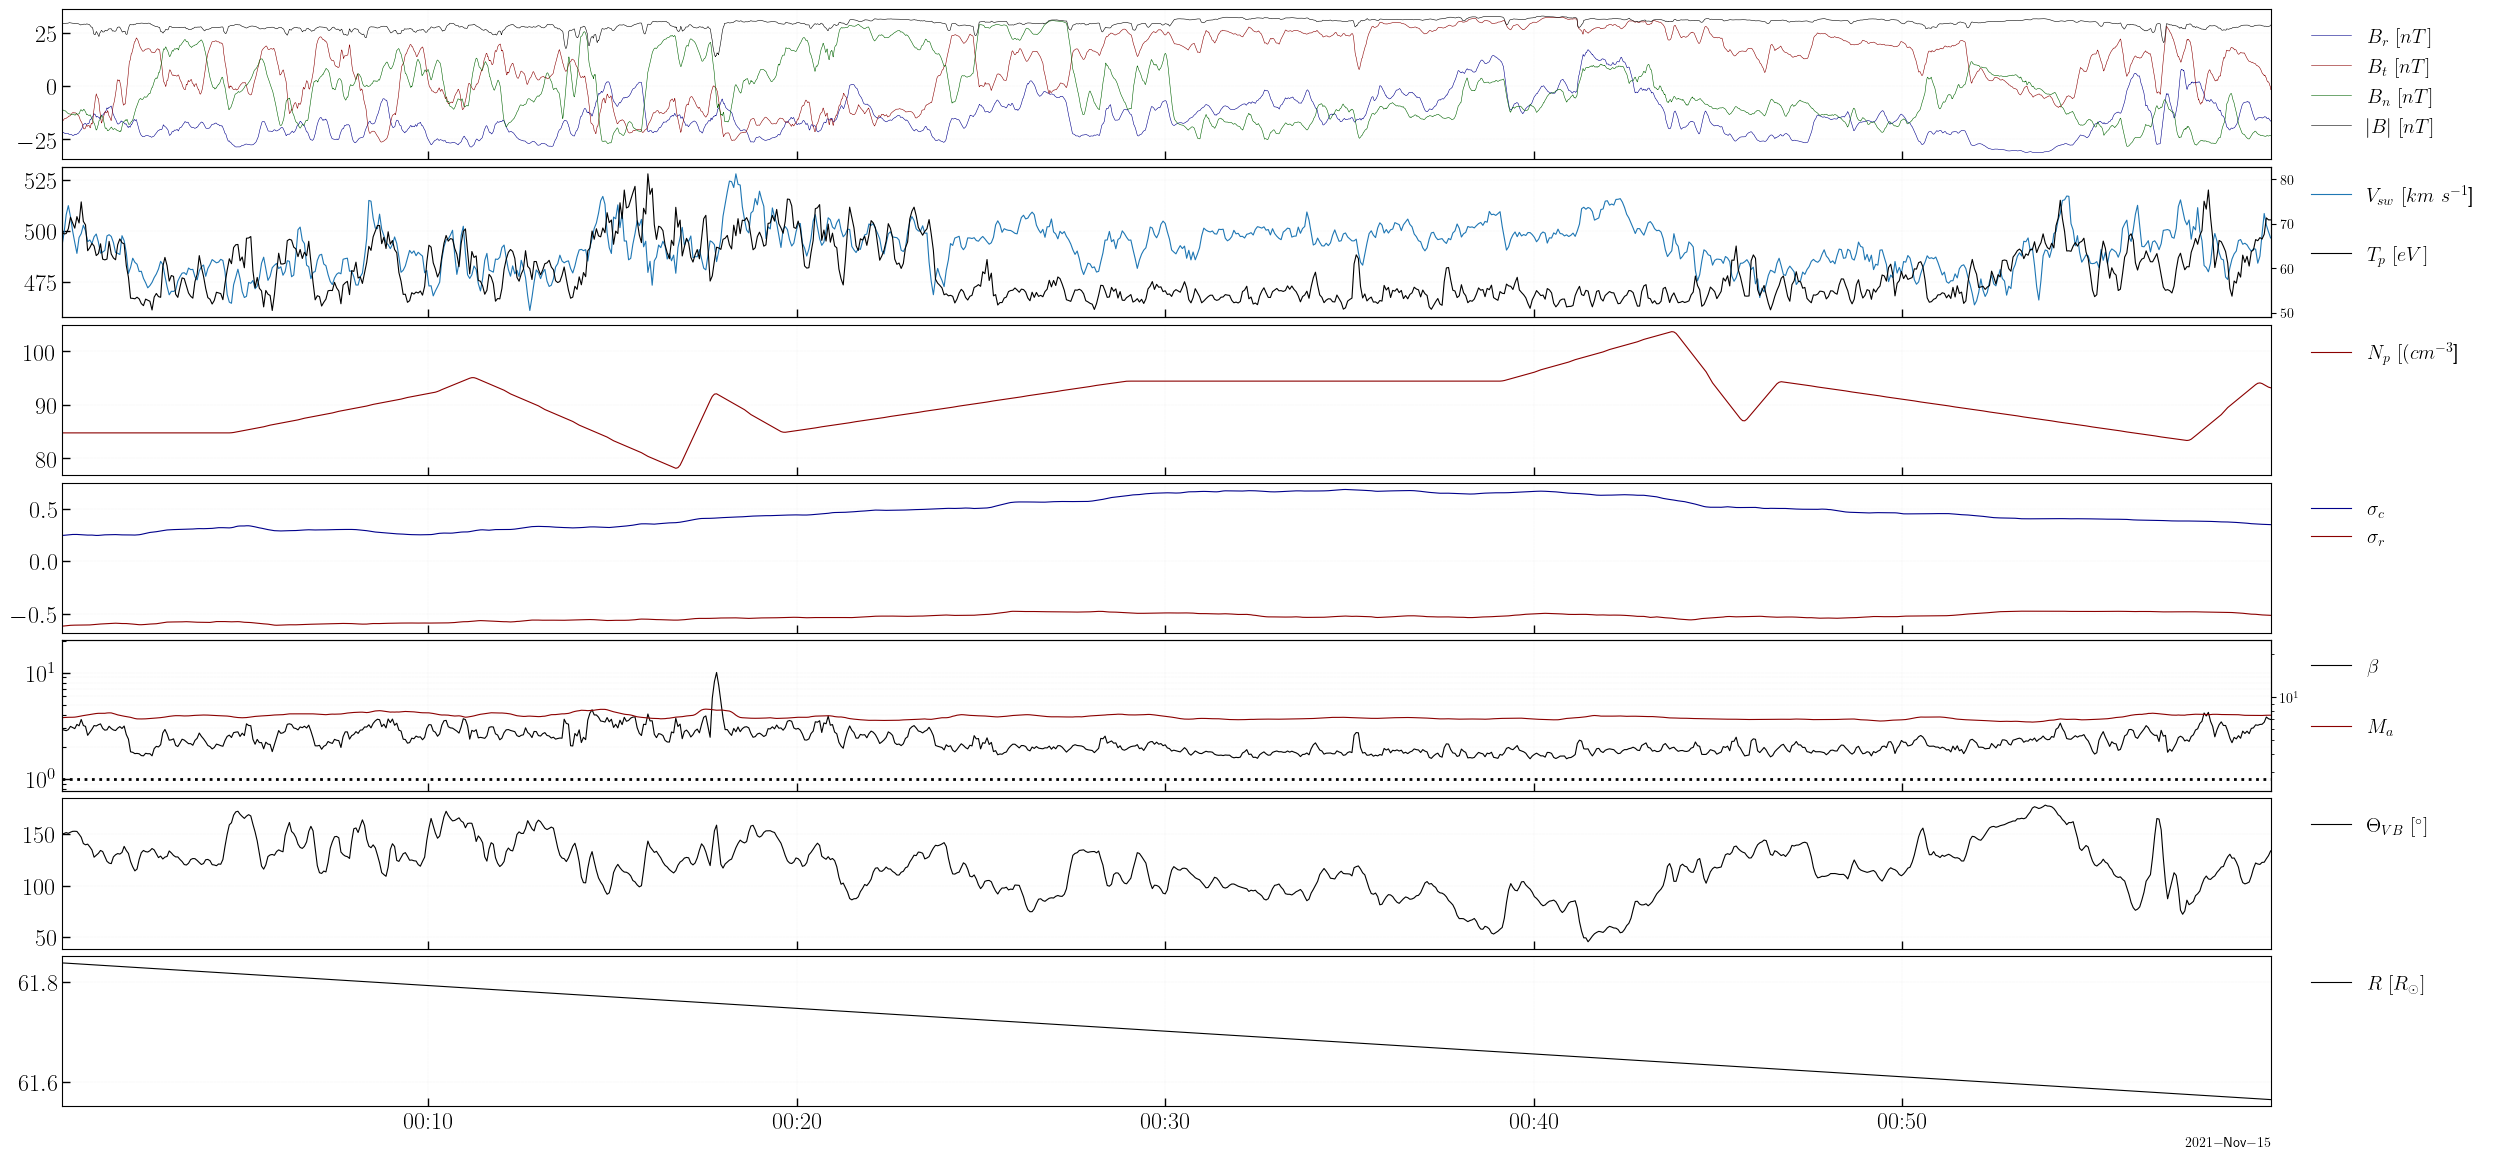

In [9]:
#  User defined parameters
sc          = 'PSP'
which_int   = 0
load_path = USER_PATHS['save_destination']


# Locate the downloaded files
finnames      = func.load_files(load_path, 'final.pkl')
gennames      = func.load_files(load_path, 'general.pkl')
signames      = func.load_files(load_path, 'sig_c_sig_r.pkl')
maggaps       = func.load_files(load_path, 'mag_gaps.pkl')
qtngaps       = func.load_files(load_path, 'qtn_gaps.pkl')
pargaps       = func.load_files(load_path, 'par_gaps.pkl')
sc_pot        = func.load_files(load_path, 'sc_pot_gaps.pkl')


#Load the filed
fin         = pd.read_pickle(finnames[which_int])
gen         = pd.read_pickle(gennames[which_int])
sig         = pd.read_pickle(signames[which_int])
mag_gaps    = pd.read_pickle(maggaps[which_int])
qtn_gaps    = pd.read_pickle(qtngaps[which_int])
par_gaps    = pd.read_pickle(pargaps[which_int])
sc_pot_gaps = pd.read_pickle(sc_pot[which_int])

finnames[which_int]

# user defined parameters
w                 = '10s'
sc                = 'ACE'
label_size        = 21                                    # labels etc

n_subplots        = 7                                     # number os subplots
my_dir            = USER_PATHS["save_destination"] #
format_2_return   = "%Y_%m_%d"                            # Format to save figures


figs.visualize_downloaded_intervals(
                                  sc                         ,
                                  fin['Par']['V_resampled'].rolling(w, center=True).mean() ,
                                  fin['Mag']['B_resampled'].rolling(w, center=True).mean() ,
                                  sig.rolling(w, center=True).mean()   ,
                                  my_dir,
                                  format_2_return  = "%Y_%m_%d",  #
                                  size             = label_size,
                                  numb_subplots    = n_subplots
                                 )



In [16]:
figw, events = interactive_figures.interactive_mhdturbpy_interval(
    sc=sc,
    which_int=which_int,
    load_path=load_path,
    save_path=str(Path(my_dir) / "selected_intervals"),
    rolling=w,
    resample_rule="10s",
    fill_method=None,
    gap_thresholds={"mag": "30s", "par": "30s", "qtn": "30s", "sc_pot": "30s"},
)


    'data': [{'mode': 'lines',
              'name': 'Br',
              'showle…

In [12]:
import sys, plotly
print("kernel python:", sys.executable)
print("plotly:", plotly.__version__)


kernel python: /Users/turbulator/miniforge3/envs/mhdturbpy/bin/python
plotly: 6.5.2
